# Text Preprocessing
## Sentiment Analysis Review Mobile Legends

## 1. Load Dataset

In [3]:
import pandas as pd

# load dataset
df = pd.read_csv('../data/mobile_legends_reviews_cleaned1.csv')

print(df.head())
print(df.shape)

                               reviewId         userName  \
0  a88d9682-8a77-433a-825c-493070197e3d  Pengguna Google   
1  97add647-794f-42eb-a02e-fd58f5a424a5  Pengguna Google   
2  c1482b0d-47a9-422f-a30c-df75e8624192  Pengguna Google   
3  a6efbddf-25c1-4de5-bf04-7fe3109e0b96  Pengguna Google   
4  7f35b682-b6f4-40ec-a3bd-41b9e8e5f3f8  Pengguna Google   

                                           userImage  \
0  https://play-lh.googleusercontent.com/EGemoI2N...   
1  https://play-lh.googleusercontent.com/EGemoI2N...   
2  https://play-lh.googleusercontent.com/EGemoI2N...   
3  https://play-lh.googleusercontent.com/EGemoI2N...   
4  https://play-lh.googleusercontent.com/EGemoI2N...   

                                             content  score  thumbsUpCount  \
0  Aku turunkan rating bintang nya. Tolong pelaku...      1           5129   
1  Game nya diperbarui lagi lah! Enak enak main r...      1           1090   
2  Kondisi lag saat di tengah game sering banget ...      1         

## 2. Membuat Label Sentimen

In [6]:
def convert_sentiment(score):
    if score <= 2:
        return 'negatif'
    elif score == 3:
        return 'netral'
    else:
        return 'positif'


df['sentiment'] = df['score'].apply(convert_sentiment)

print(df[['score', 'sentiment']].head())
print(df['sentiment'].value_counts())

   score sentiment
0      1   negatif
1      1   negatif
2      1   negatif
3      3    netral
4      1   negatif
sentiment
negatif    6747
positif    2373
netral      880
Name: count, dtype: int64


## 3. Ambil Kolom yang Dipakai

In [7]:
# hanya gunakan isi review dan label

df = df[['content', 'sentiment']]

# hapus data kosong

df = df.dropna()

# hapus review kosong

df = df[df['content'].str.strip() != '']

print(df.head())

                                             content sentiment
0  Aku turunkan rating bintang nya. Tolong pelaku...   negatif
1  Game nya diperbarui lagi lah! Enak enak main r...   negatif
2  Kondisi lag saat di tengah game sering banget ...   negatif
3  Montonnnnn, gimana sih. Gak sekali dua kali pa...    netral
4  Sama saja kasih skin tapi dibuat kalah terus. ...   negatif


## 4. Preprocessing Teks

In [10]:
import re
import string
from tqdm import tqdm
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

tqdm.pandas()

stop_words = set(stopwords.words('indonesian'))
stemmer = StemmerFactory().create_stemmer()

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    words = [w for w in text.split() if w not in stop_words]

    # batasi jumlah kata agar tidak terlalu berat
    text = ' '.join(words[:100])

    return stemmer.stem(text)

df['clean_text'] = df['content'].progress_apply(clean_text)

100%|██████████| 10000/10000 [25:59<00:00,  6.41it/s] 


## 5. Cek Distribusi Label

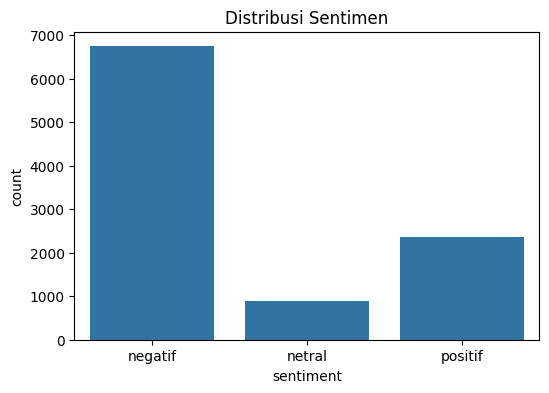

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment')
plt.title('Distribusi Sentimen')
plt.show()

## 6. Simpan Hasil Preprocessing

In [13]:
# hapus hasil preprocessing yang kosong
df = df[df['clean_text'].str.strip() != '']

# hapus duplikat setelah preprocessing
df = df.drop_duplicates(subset=['clean_text', 'sentiment'])

# simpan hasil preprocessing
df_final = df[['clean_text', 'sentiment']]
df_final.to_csv('../data/ml_reviews_ready.csv', index=False)

print(df_final.shape)
print(df_final.head())

(9996, 2)
                                          clean_text sentiment
0  turun rating bintang nya tolong laku cheat rw ...   negatif
1  game nya baru enak enak main rank reset dibiar...   negatif
2  kondisi lag game banget jumpa cheat bug barusa...   negatif
3  montonnnnn gimana sih gak kali pas tengahtenga...    netral
4  kasih skin kalah musuh kasih musuh musuh berat...   negatif
